In [1]:
## Multi-Image Spectral Standardization – BIRCH (partial_fit) + DBSCAN Clustering

import os
import sys
from pathlib import Path
sys.path.insert(0, str(Path(os.getcwd()).parent))

import numpy as np
import matplotlib.pyplot as plt
import tifffile
import gc

from tqdm import tqdm
from sklearn.cluster import Birch, DBSCAN
import glob

import shutil

In [2]:

# ==================== Helper Functions ====================

def normalize(array, max_val=None, min_val=None, axis=None):
    """
    Normalize array to specified range.
    
    Args:
        array: Input array (1D or 2D) - numpy array
        max_val: Maximum value for normalized output (computed from data if None)
        min_val: Minimum value for normalized output (computed from data if None)
        axis: For 2D arrays only - axis along which to normalize
              axis=0: normalize each column, axis=1: normalize each row
              axis=None: global normalization
              For 1D arrays, axis parameter is ignored
    
    Returns:
        Normalized numpy array
    """
    array = np.asarray(array, dtype=np.float32)

    # For 1D arrays, ignore axis parameter
    if array.ndim == 1:
        axis = None
    
    # Calculate min/max if not provided
    if axis is None:
        # Global normalization
        if max_val is None:
            max_val = np.max(array)
            max_val = max_val.astype(np.float32)
        if min_val is None:
            min_val = np.min(array)
            min_val = min_val.astype(np.float32)
        
        diff = (max_val - min_val).astype(np.float32)
        normalized_spectra = (array - min_val) / diff + 1e-6

        return normalized_spectra
    else:
        # Axis-based normalization for 2D arrays
        if max_val is None:
            max_val = np.max(array, axis=axis, keepdims=True)
            max_val = max_val.astype(np.float32)
        if min_val is None:
            min_val = np.min(array, axis=axis, keepdims=True)
            min_val = min_val.astype(np.float32)
        
        diff = (max_val - min_val).astype(np.float32)
        return (array - min_val) / diff + 1e-6


def spectral_standardization(data, wavenum_1, wavenum_2, num_samp, background, ch_start=None):
    """
    Apply spectral standardization to hyperspectral data.
    
    Parameters
    ----------
    data : numpy.ndarray of shape (N, num_samp)
        Hyperspectral data where N is number of pixels
    wavenum_1 : float
        Starting wavenumber
    wavenum_2 : float
        Ending wavenumber
    num_samp : int
        Number of samples
    background : numpy.ndarray of shape (num_samp,)
        Background spectrum
    ch_start : int, optional
        Channel index for silent region
    
    Returns
    -------
    spectra : numpy.ndarray of shape (N, num_samp)
        Standardized spectra
    """
    if ch_start is None:
        ch_start = int((2800 - wavenum_1) / (wavenum_2 - wavenum_1) * num_samp)
    
    # Normalize input data
    data = np.asarray(data, dtype=np.float32)
    
    # Validate shape
    if data.shape[1] != num_samp:
        raise ValueError(
            f"Data channel mismatch: Expected {num_samp} channels, got {data.shape[1]}. "
            f"Check that the correct image files are being loaded. "
            f"Image shape: {data.shape}"
        )
    
    temp_norm = normalize(data)
    
    # Extract tail and head regions
    temp_end = temp_norm[:, -1:-4:-1]
    temp_start = temp_norm[:, :ch_start]
    
    # Remove baseline from silent region
    temp = temp_norm-np.mean(temp_start,axis=1)[:, np.newaxis]
    
    # Estimate background magnitude
    spectra_magnitude = np.mean(temp_end, axis=1) - np.mean(temp_start, axis=1)
    background_arr = np.outer(spectra_magnitude, background)
    
    # Subtract background
    spectra_standard = (temp - background_arr).astype(np.float32)
    
    # Normalize to background-removed spectrum
    spectra_max_idx = np.argmax(np.mean(spectra_standard, axis=0))
    max_val = np.mean(spectra_standard[:, spectra_max_idx]) + 3 * np.std(spectra_standard[:, spectra_max_idx]).astype(np.float32)  
    min_val = np.mean(spectra_standard[:, :ch_start]) - 3 * np.std(spectra_standard[:, :ch_start]).astype(np.float32)
    spectra_norm = normalize(
        spectra_standard,
        max_val=max_val,
        min_val=min_val,
        axis=1
    )
    
    return spectra_norm.astype(np.float32)


def standardize_and_save_images(image_paths, wn_1, wn_2, num_samp, background, ch_start, output_dir=r"clustering/standardized_data"):
    """
    Standardize images and save to disk to avoid memory issues.
    Also returns metadata about pixel counts per image.
    
    Parameters
    ----------
    image_paths : list
        List of image file paths
    output_dir : str
        Directory to save standardized data
    
    Returns
    -------
    standardized_info : dict
        Dictionary with 'paths', 'pixels', and 'shapes' for each standardized image
    """
    os.makedirs(output_dir, exist_ok=True)
    
    standardized_info = {
        "name": [],
        "paths": [],
        "pixels": [],
        "shapes": []
    }
    
    total_pixels = 0
    
    for img_idx, img_path in enumerate(tqdm(image_paths, desc="Standardizing and saving images")):
        print(f"\nProcessing image {img_idx}: {os.path.basename(img_path)}")
        
        # Load and reshape image
        image_memmap = tifffile.memmap(img_path, mode='r')
        
        # Handle different TIFF formats
        # If shape is (height, width, channels), transpose to (channels, height, width)
        if image_memmap.ndim == 3:
            if image_memmap.shape[0] > image_memmap.shape[2]:  # Likely (height, width, channels)
                image_memmap = np.transpose(image_memmap, (2, 0, 1))
        
        # Reshape: (channels, height, width) -> (height*width, channels)
        reshaped = image_memmap.reshape((image_memmap.shape[0], -1)).T
        reshaped = np.asarray(reshaped)
        
        # Flip to match original orientation
        raw_data = np.flip(reshaped, axis=1)
        print(f"  Shape: {raw_data.shape}")
        
        # Standardize spectra for this image
        standardized = spectral_standardization(raw_data, wn_1, wn_2, num_samp, background, ch_start)
        
        # Save standardized data to disk
        output_path = os.path.join(output_dir, f"standardized_{img_idx:03d}.npy")
        np.save(output_path, standardized.astype(np.float32))
        
        num_pixels = standardized.shape[0]
        height, width = image_memmap.shape[1:]
        
        standardized_info["name"].append(os.path.basename(img_path))
        standardized_info["paths"].append(output_path)
        standardized_info["pixels"].append(num_pixels)
        standardized_info["shapes"].append((height, width))
        
        total_pixels += num_pixels
        
        print(f"  Standardized shape: {standardized.shape}")
    
    print(f"\nTotal pixels standardized and saved: {total_pixels:,}")
    return standardized_info


def load_batch_data(info, batch_size=50000):
    """
    Generator to load standardized data in batches for clustering.
    Yields batches of spectra from the standardized images to reduce memory load.
    Parameters
    ----------
    info : dict
        Dictionary with 'paths' and 'pixels' for each standardized image
    batch_size : int
        Number of spectra to yield in each batch
    Returns
    -------
    batch_data : numpy.ndarray
        Batch of spectra for clustering
    """
    buffer = []  # Buffer to accumulate pixels across batches
    for file_path in info["paths"]:
        data_mmap = np.load(file_path, mmap_mode='r')
        num_pixels = data_mmap.shape[0]
        chunk_size = min(batch_size * 2, 100000)  # Process in reasonable chunks
        for chunk_start in range(0, num_pixels, chunk_size):
            chunk_end = min(chunk_start + chunk_size, num_pixels)
            chunk = np.array(data_mmap[chunk_start:chunk_end])
            buffer.append(chunk)
            while len(buffer) > 0:
                combined = np.vstack(buffer) if len(buffer) > 1 else buffer[0]
                if combined.shape[0] >= batch_size:
                    num_full_batches = combined.shape[0] // batch_size
                    for batch_idx in range(num_full_batches):
                        start = batch_idx * batch_size
                        end = start + batch_size
                        yield combined[start:end]
                    remainder = combined[num_full_batches * batch_size:]
                    if len(remainder) > 0:
                        buffer = [remainder]
                    else:
                        buffer = []
                    break
                else:
                    break
            del chunk
            gc.collect()
        del data_mmap
        gc.collect()
    if len(buffer) > 0:
        remaining = np.vstack(buffer) if len(buffer) > 1 else buffer[0]
        if remaining.shape[0] > 0:
            yield remaining


def _accumulate_centers(labels_arr, data_arr, all_unique, label_offset, centers, center_counts):
    """
    Vectorized accumulation of per-cluster sums and counts using np.add.at.
    Faster than a Python-level loop over unique labels.
    """
    row_indices = labels_arr + label_offset  # shift -1 -> 0 if label_offset==1
    np.add.at(centers, row_indices, data_arr)
    np.add.at(center_counts, row_indices, 1)


def batch_birch_model(threshold=0.5, branching_factor=50, n_clusters=None):
    """
    Create a BIRCH model for incremental partial_fit clustering.
    n_clusters is set to None so that BIRCH retains raw subclusters;
    DBSCAN is applied to those subcluster centroids afterward.

    Parameters
    ----------
    threshold : float
        Radius of the subcluster CF node (smaller = more subclusters, slower DBSCAN).
        Recommended range: 0.3 – 1.0.
    branching_factor : int
        Maximum number of CF subclusters in each node.

    Returns
    -------
    birch_model : sklearn.cluster.Birch
    """
    birch_model = Birch(n_clusters=n_clusters, threshold=threshold, branching_factor=branching_factor)
    return birch_model


def cluster_spectra(birch_model, dbscan_params, info, batch_size=50000):
    """
    Three-pass clustering with BIRCH partial_fit followed by DBSCAN.

    Pass 1 – BIRCH partial_fit: incrementally build the CF tree.
    DBSCAN: cluster the BIRCH subcluster centroids.
    Pass 2 – Predict: map each pixel through BIRCH subcluster index
             then through the DBSCAN label array.
    Pass 3 – Centers: compute per-cluster mean spectra (vectorized).

    Parameters
    ----------
    birch_model : sklearn.cluster.Birch
    dbscan_params : dict
        Keyword arguments forwarded to DBSCAN (e.g. eps, min_samples).
        Tip: add algorithm='ball_tree' or 'kd_tree' to speed up DBSCAN.
    info : dict
        Dictionary with 'paths' and 'pixels' for each standardized image.
    batch_size : int

    Returns
    -------
    all_labels : numpy.ndarray  (int32, noise pixels labelled -1)
    centers    : numpy.ndarray  shape (n_dbscan_clusters, n_channels)
    dbscan_label_array : numpy.ndarray mapping birch subcluster index -> dbscan label
    """
    total_pixels = sum(info["pixels"])

    # ---- Pass 1: BIRCH partial_fit ----
    print("Pass 1: BIRCH partial_fit on batches...")
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="BIRCH partial_fit"):
        non_zero_mask = np.std(batch_data, axis=1) > 1e-2
        batch_filtered = batch_data[non_zero_mask]
        if batch_filtered.shape[0] > 0:
            birch_model.partial_fit(batch_filtered)
        del batch_data, batch_filtered
        gc.collect()

    # ---- DBSCAN on BIRCH subcluster centroids ----
    subcluster_centers = birch_model.subcluster_centers_
    print(f"  BIRCH produced {subcluster_centers.shape[0]} subclusters")
    print(f"  Running DBSCAN on subcluster centroids...")
    dbscan = DBSCAN(**dbscan_params)
    dbscan_label_array = dbscan.fit_predict(subcluster_centers)
    unique_db_labels = np.unique(dbscan_label_array)
    n_db_clusters = np.sum(unique_db_labels >= 0)
    n_noise = np.sum(dbscan_label_array == -1)
    print(f"  DBSCAN found {n_db_clusters} clusters, {n_noise} noise subclusters")

    # ---- Pass 2: Predict pixel labels ----
    print("Pass 2: Predicting pixel labels...")
    labels = np.full(total_pixels, -1, dtype=np.int32)
    pixel_count = 0
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="Predicting labels"):
        batch_size_actual = batch_data.shape[0]
        non_zero_mask = np.std(batch_data, axis=1) > 1e-2
        batch_filtered = batch_data[non_zero_mask]

        if batch_filtered.shape[0] > 0:
            subcluster_idx = birch_model.predict(batch_filtered)
            pixel_labels = dbscan_label_array[subcluster_idx]
            global_indices = np.where(non_zero_mask)[0] + pixel_count
            labels[global_indices] = pixel_labels

        pixel_count += batch_size_actual
        del batch_data, batch_filtered
        gc.collect()

    # ---- Pass 3: Compute per-cluster mean spectra (vectorized) ----
    print("Pass 3: Computing cluster centers...")
    all_unique = np.unique(labels)  # includes -1 if present
    label_offset = 1 if -1 in all_unique else 0
    n_channels = subcluster_centers.shape[1]
    centers = np.zeros((len(all_unique), n_channels), dtype=np.float64)
    center_counts = np.zeros(len(all_unique), dtype=np.int64)

    pixel_count = 0
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="Computing centers"):
        batch_size_actual = batch_data.shape[0]
        batch_labels = labels[pixel_count:pixel_count + batch_size_actual]
        _accumulate_centers(batch_labels, batch_data.astype(np.float64),
                            all_unique, label_offset, centers, center_counts)
        pixel_count += batch_size_actual
        del batch_data
        gc.collect()

    nonzero = center_counts > 0
    centers[nonzero] /= center_counts[nonzero, np.newaxis]
    centers = centers.astype(np.float32)

    return labels, centers, dbscan_label_array


def cluster_normalized_spectra(birch_model, dbscan_params, info, reorg_centers, reorg_labels, ch_start, batch_size=50000):
    """
    Re-normalize non-background spectra (reorg_labels != -1 and >= 1) then
    re-run BIRCH partial_fit + DBSCAN.

    Background pixels (label == -1 or 0) are excluded from fitting.

    Parameters
    ----------
    birch_model : Birch
        Fresh Birch instance (not yet fitted).
    dbscan_params : dict
    info : dict
    reorg_centers : ndarray
    reorg_labels : ndarray
        Labels from the first clustering pass. 0 or -1 == background.
    ch_start : int
    batch_size : int

    Returns
    -------
    norm_labels : ndarray
    norm_centers : ndarray
    """
    total_pixels = sum(info["pixels"])

    # Determine background label (lowest label in reorg_labels)
    bg_label = np.min(reorg_labels)

    # --- Plot current centers for reference ---
    unique_labels, counts = np.unique(reorg_labels, return_counts=True)
    for label, count in zip(unique_labels, counts):
        print(f"  Label {label}: {count} pixels")
        print(f"  Std. of center {label} is {np.std(reorg_centers[label])}")
        plt.plot(reorg_centers[label], label=f'Cluster {label}')
    plt.legend()
    plt.title("BIRCH+DBSCAN Cluster Centers Before Re-normalization")
    plt.xlabel("Channel")
    plt.ylabel("Intensity")
    plt.grid(True, alpha=0.3)
    plt.show()

    # ---- Pass 1: BIRCH partial_fit on re-normalized non-background spectra ----
    print("\nPass 1: Fitting BIRCH on re-normalized spectra...")
    pixel_count = 0
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="BIRCH partial_fit (normalized)"):
        batch_size_actual = batch_data.shape[0]
        batch_labels = reorg_labels[pixel_count:pixel_count + batch_size_actual]

        non_bg_mask = batch_labels > bg_label
        if np.any(non_bg_mask):
            batch_non_bg = batch_data[non_bg_mask]
            max_vals = np.max(batch_non_bg, axis=1, keepdims=True)
            min_vals = np.mean(batch_non_bg[:, :ch_start], axis=1, keepdims=True)
            batch_normalized = normalize(batch_non_bg, max_val=max_vals, min_val=min_vals, axis=1)
            birch_model.partial_fit(batch_normalized)
            del batch_non_bg, batch_normalized, max_vals, min_vals

        pixel_count += batch_size_actual
        del batch_data
        gc.collect()

    # ---- DBSCAN on BIRCH subcluster centroids ----
    subcluster_centers = birch_model.subcluster_centers_
    print(f"  BIRCH produced {subcluster_centers.shape[0]} subclusters (normalized)")
    dbscan = DBSCAN(**dbscan_params)
    dbscan_label_array = dbscan.fit_predict(subcluster_centers)
    unique_db = np.unique(dbscan_label_array)
    print(f"  DBSCAN found {np.sum(unique_db >= 0)} clusters, {np.sum(dbscan_label_array == -1)} noise subclusters")

    # ---- Pass 2: Predict normalized labels ----
    print("\nPass 2: Predicting normalized cluster labels...")
    norm_labels = np.full(total_pixels, bg_label, dtype=np.int32)
    pixel_count = 0
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="Predicting normalized clusters"):
        batch_size_actual = batch_data.shape[0]
        batch_labels = reorg_labels[pixel_count:pixel_count + batch_size_actual]

        non_bg_mask = batch_labels > bg_label
        if np.any(non_bg_mask):
            batch_non_bg = batch_data[non_bg_mask]
            max_vals = np.max(batch_non_bg, axis=1, keepdims=True)
            min_vals = np.mean(batch_non_bg[:, :ch_start], axis=1, keepdims=True)
            batch_normalized = normalize(batch_non_bg, max_val=max_vals, min_val=min_vals, axis=1)

            subcluster_idx = birch_model.predict(batch_normalized)
            predicted_labels = dbscan_label_array[subcluster_idx]

            global_indices = np.where(non_bg_mask)[0] + pixel_count
            norm_labels[global_indices] = predicted_labels
            del batch_non_bg, batch_normalized, max_vals, min_vals

        pixel_count += batch_size_actual
        del batch_data
        gc.collect()

    # ---- Pass 3: Compute cluster centers (vectorized) ----
    print("Pass 3: Computing normalized cluster centers...")
    all_unique = np.unique(norm_labels)
    label_offset = 1 if -1 in all_unique else 0
    n_channels = subcluster_centers.shape[1]
    norm_centers = np.zeros((len(all_unique), n_channels), dtype=np.float64)
    center_counts = np.zeros(len(all_unique), dtype=np.int64)

    pixel_count = 0
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="Computing normalized centers"):
        batch_size_actual = batch_data.shape[0]
        batch_labels = norm_labels[pixel_count:pixel_count + batch_size_actual]
        _accumulate_centers(batch_labels, batch_data.astype(np.float64),
                            all_unique, label_offset, norm_centers, center_counts)
        pixel_count += batch_size_actual
        del batch_data
        gc.collect()

    nonzero = center_counts > 0
    norm_centers[nonzero] /= center_counts[nonzero, np.newaxis]
    norm_centers = norm_centers.astype(np.float32)

    return norm_labels, norm_centers


def reorganize_labels_clusters(labels, centers):
    """
    Reorganize cluster labels based on cluster center std (ascending).
    Noise pixels (label == -1) are remapped to 0 (lowest index).

    Parameters
    ----------
    labels : numpy.ndarray
    centers : numpy.ndarray

    Returns
    -------
    reorg_labels : numpy.ndarray
    reorg_centers : numpy.ndarray
    """
    reorg_idx = np.argsort(np.std(centers, axis=1))
    reorg_centers = centers[reorg_idx]
    reorg_labels = np.zeros_like(labels)
    for new_idx, old_idx in enumerate(reorg_idx):
        reorg_labels[labels == old_idx] = new_idx
    # Noise pixels (-1) -> 0 (background)
    reorg_labels[labels == -1] = 0
    return reorg_labels, reorg_centers


def plot_cluster_spectra(num_clusters, reorg_centers, wn_1, wn_2, num_samp, file_name, save_dir):
    """
    Interactive color assignment for cluster center visualization.
    """
    default_colors = [
            '#000000', '#FF0000', '#00FF00', '#0000FF', 
            '#FFFF00', '#FF00FF', '#00FFFF', '#FFA500',
            '#800080', '#008080'
        ]
    
    print(f"\nSelect hexadecimal colors for cluster centers:")
    wavenumbers = np.linspace(wn_1, wn_2, num_samp)
    fig, ax = plt.subplots(figsize=(12, 6))
    color_list = []

    for i in range(num_clusters):
        default_color = default_colors[i % len(default_colors)]
        user_input = input(f'  Cluster {i} (default: {default_color}): ').strip()
        color = user_input if user_input else default_color
        color_list.append(color)
        ax.plot(wavenumbers, reorg_centers[i], color=color, linewidth=2, label=f'Cluster {i}')

    ax.set_xlabel('Wavenumbers (cm\u207b\u00b9)', fontsize=16)
    ax.set_ylabel('Normalized Intensity (A.U.)', fontsize=16)
    ax.set_title('BIRCH + DBSCAN Cluster Centers', fontsize=18)
    ax.legend(loc='best', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    filename = file_name
    plt.savefig(os.path.join(save_dir, filename), dpi=300)
    print(f"Saved cluster centers plot as '{filename}'")
    print(f"\nCluster colors assigned:")
    for i, color in enumerate(color_list):
        print(f"  Cluster {i}: {color}")

    response = input(f"\nDo you want to reassign colors? (yes/no) (View current cluster colors in {save_dir}): ").strip().lower()
    
    if response in ('yes', 'y'):
        print("\nEnter new hexadecimal colors for each cluster (or press Enter to keep current):")
        new_color_list = []
        for i in range(num_clusters):
            user_input = input(f'  Cluster {i} (current: {color_list[i]}): ').strip()
            new_color = user_input if user_input else color_list[i]
            new_color_list.append(new_color)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        for i in range(num_clusters):
            ax.plot(wavenumbers, reorg_centers[i], color=new_color_list[i], linewidth=2, label=f'Cluster {i}')
        ax.set_xlabel('Wavenumbers (cm\u207b\u00b9)', fontsize=12)
        ax.set_ylabel('Normalized Intensity (A.U.)', fontsize=12)
        ax.set_title('BIRCH + DBSCAN Cluster Centers - Updated Colors', fontsize=14)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        print(f"Saved cluster centers plot as '{filename}'")
        print(f"\nCluster colors assigned:")
        for i, color in enumerate(new_color_list):
            print(f"  Cluster {i}: {color}")
    else:
        new_color_list = color_list

    return new_color_list


def reconstruct_cluster_images(reorg_labels, info, color_list, batch_size=50000):
    """
    Reconstruct and colorize clustered images using batches.
    """
    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip('#')
        return np.array([int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4)], dtype=np.float32)
    
    color_map = np.array([hex_to_rgb(c) for c in color_list])
    reconstructed_images = [None] * len(info['name'])
    
    print("Reconstructing images in batches...")
    reorg_labels = np.where(np.isnan(reorg_labels.astype(float)), 0, reorg_labels).astype(int)
    # Clamp any remaining -1 (noise) to 0
    reorg_labels = np.clip(reorg_labels, 0, len(color_list) - 1)
    total_pixels = len(reorg_labels)
    
    for batch_start in tqdm(range(0, total_pixels, batch_size), desc="Reconstructing images"):
        batch_end = min(batch_start + batch_size, total_pixels)
        batch_labels = reorg_labels[batch_start:batch_end]
        batch_rgb = color_map[batch_labels.astype(int)]
        
        current_pixel = batch_start
        for img_idx in range(len(info['name'])):
            img_pixel_start = sum(info['pixels'][:img_idx])
            img_pixel_end = img_pixel_start + info['pixels'][img_idx]
            
            overlap_start = max(current_pixel, img_pixel_start)
            overlap_end = min(batch_end, img_pixel_end)
            
            if overlap_start < overlap_end:
                if reconstructed_images[img_idx] is None:
                    height, width = info['shapes'][img_idx]
                    reconstructed_images[img_idx] = np.zeros((height * width, 3), dtype=np.float32)
                
                batch_offset_start = overlap_start - batch_start
                batch_offset_end = overlap_end - batch_start
                img_offset_start = overlap_start - img_pixel_start
                img_offset_end = overlap_end - img_pixel_start
                
                reconstructed_images[img_idx][img_offset_start:img_offset_end] = batch_rgb[batch_offset_start:batch_offset_end]
    
    final_images = []
    for img_idx, img_pixels in enumerate(reconstructed_images):
        height, width = info['shapes'][img_idx]
        img_2d = img_pixels.reshape((height, width, 3))
        final_images.append(img_2d)
    
    return final_images


def display_reconstructed_images(reconstructed_images, info, save_dir, figsize_per_image=(5, 5)):
    """
    Display reconstructed clustered images.
    """
    num_images = len(reconstructed_images)
    cols = min(3, num_images)
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0], rows * figsize_per_image[1]))
    
    if num_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for img_idx, image_2d in enumerate(reconstructed_images):
        ax = axes[img_idx]
        ax.imshow(image_2d, aspect='auto', interpolation='nearest')
        ax.set_title(f'{info["name"][img_idx]} - Clustered', fontsize=12)
        ax.set_xlabel('Width (pixels)')
        ax.set_ylabel('Height (pixels)')
    
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'clustered_images.png'), dpi=300)
    plt.show()
    print(f"Displayed {num_images} clustered images")


In [3]:
# ==================== Configuration ====================
# Hyperspectral image parameters
wn_1 = 2700
wn_2 = 3100
num_samp = 61
ch_start = int((2800 - wn_1) / (wn_2 - wn_1) * num_samp)

# Data directories
base_dir = os.path.dirname(os.getcwd())
clustering_dir = os.path.join(base_dir, 'clustering')
image_dir = r"D:\ADATA Backup\HuBMAP\HuBMAP CODEX\integrated_pipeline\S21_data"
srs_params_path = os.path.join(base_dir, 'params_dataset', 'srs_params_61.npz')

# Standardized data temp folder
standardized_dir = os.path.join(clustering_dir, 'standardized_data')

# Output images/plots folder
output_base = os.path.basename(os.path.normpath(image_dir)) + '_dbscan_output_images'
output_dir = os.path.join(clustering_dir, output_base)
os.makedirs(output_dir, exist_ok=True)

# Load background from SRS parameters
srs_data = np.load(srs_params_path)
background_spectrum = srs_data['background']

In [4]:
# ==================== Main Workflow ====================
print("\n" + "="*60)
print("Configuration:")
print(f"  Wavenumber range: {wn_1}-{wn_2} cm⁻¹")
print(f"  Number of samples: {num_samp}")
print(f"  Channel start: {ch_start}")
print(f"  Background spectrum shape: {background_spectrum.shape}")
print("="*60 + "\n")

# Find images
image_paths = sorted(glob.glob(os.path.join(image_dir, '*.tif')))

if not image_paths:
    print(f"ERROR: No .tif files found in {image_dir}")
    raise FileNotFoundError(f"No .tif files found in {image_dir}")

print(f"Found {len(image_paths)} images")


Configuration:
  Wavenumber range: 2700-3100 cm⁻¹
  Number of samples: 61
  Channel start: 15
  Background spectrum shape: (61,)

Found 18 images


Standardizing images and saving to disk...


Standardizing and saving images:   0%|          | 0/18 [00:00<?, ?it/s]


Processing image 0: S21-DistalNephron-ROI1-HSI-781.3-806.5-250mW-zoom2-20us-70k--.2offset.tif
  Shape: (1048576, 61)


Standardizing and saving images:   6%|▌         | 1/18 [00:02<00:34,  2.02s/it]

  Standardized shape: (1048576, 61)

Processing image 1: S21-DistalNephron-ROI2-HSI-781.3-806.5-250mW-zoom2-20us-70k--.2offset.tif
  Shape: (1048576, 61)


...

  Standardized shape: (1048576, 61)

Processing image 16: S21-TAL-ROI2.tif
  Shape: (1048576, 61)


Standardizing and saving images:  94%|█████████▍| 17/18 [00:28<00:01,  1.61s/it]

  Standardized shape: (1048576, 61)

Processing image 17: S21-TAL-ROI3.tif
  Shape: (1048576, 61)


Standardizing and saving images: 100%|██████████| 18/18 [00:30<00:00,  1.69s/it]

  Standardized shape: (1048576, 61)

Total pixels standardized and saved: 18,874,368

Sample batch shape for visualization: (10000, 61)


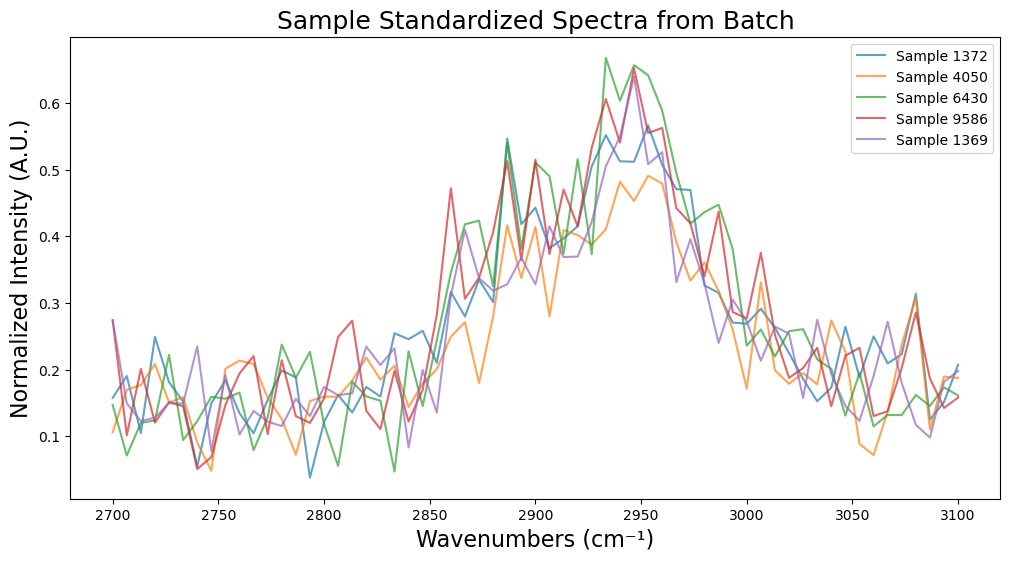

In [5]:
# ==================== STANDARDIZATION (Save to Disk) ====================
print("Standardizing images and saving to disk...")
standardized_info = standardize_and_save_images(
    image_paths, wn_1, wn_2, num_samp, background_spectrum, ch_start,
    output_dir=standardized_dir
)

# Visualize standardized spectra from first batch for sanity check
sample_batch = None
for batch_data in load_batch_data(standardized_info, batch_size=10000):
    sample_batch = batch_data
    break

del batch_data
gc.collect()

condition = np.std(sample_batch, axis=1) > 1e-2
sample_batch = sample_batch[np.where(condition)]

print(f"\nSample batch shape for visualization: {sample_batch.shape}")

random_indices = np.random.choice(sample_batch.shape[0], size=min(5, sample_batch.shape[0]), replace=False)
wavenumbers = np.linspace(wn_1, wn_2, num_samp)
plt.figure(figsize=(12, 6))
for idx in random_indices:
    plt.plot(wavenumbers, sample_batch[idx], alpha=0.7, label=f'Sample {idx}')
plt.title('Sample Standardized Spectra from Batch', fontsize=18)
plt.xlabel('Wavenumbers (cm\u207b\u00b9)', fontsize=16)
plt.ylabel('Normalized Intensity (A.U.)', fontsize=16)
plt.legend()

In [ ]:

from sklearn.preprocessing import StandardScaler
scaler_diag = StandardScaler()

# ==================== BIRCH Fit + eps Diagnostic ====================
# Fit a BIRCH model on the data to inspect subcluster centroids and
# estimate a good DBSCAN eps BEFORE running the full clustering pipeline.
#
# The k-NN distance plot: sort distances to the k-th nearest neighbor
# for each subcluster centroid. The "elbow" (sharpest upward bend) is
# a good eps value. Distances much larger than 0.3 are normal in 61D space.

from sklearn.neighbors import NearestNeighbors

# Quick BIRCH fit to get subcluster centroids for eps estimation
_birch_thresh_diag  = float(input("Enter BIRCH threshold to use for diagnostics (default 0.55): ") or 0.55)
_birch_branch_diag  = int(input("Enter BIRCH branching factor (default 200): ") or 200)
_birch_diag = batch_birch_model(threshold=_birch_thresh_diag, branching_factor=_birch_branch_diag)

print("Fitting BIRCH for eps diagnostics (with z-standardization)...")
# First pass: fit scaler on all batches
for _bd in tqdm(load_batch_data(standardized_info, batch_size=500000), desc="Fitting StandardScaler"):
    _nz = np.std(_bd, axis=1) > 1e-2
    if _nz.any():
        scaler_diag.partial_fit(_bd[_nz])
    del _bd
    gc.collect()

# Second pass: fit BIRCH on standardized data
for _bd in tqdm(load_batch_data(standardized_info, batch_size=500000), desc="BIRCH diagnostic fit"):
    _nz = np.std(_bd, axis=1) > 1e-2
    if _nz.any():
        _bd_z = scaler_diag.transform(_bd[_nz])
        _birch_diag.partial_fit(_bd_z)
    del _bd
    gc.collect()

_sc = _birch_diag.subcluster_centers_
print(f"BIRCH produced {_sc.shape[0]} subclusters with threshold={_birch_thresh_diag}")
print(f"Subcluster centroid array shape: {_sc.shape}")

# k-NN distance plot (use k=min_samples you plan to use, default 5)
_k = int(input("Enter k for kNN distance plot (= planned DBSCAN min_samples, default 5): ") or 5)
_nbrs = NearestNeighbors(n_neighbors=_k, algorithm='ball_tree').fit(_sc)
_dists, _ = _nbrs.kneighbors(_sc)
_kth_dists = np.sort(_dists[:, -1])[::-1]   # distance to k-th neighbour, descending

plt.figure(figsize=(10, 5))
plt.plot(_kth_dists, linewidth=1.5)
plt.xlabel('Subcluster index (sorted)', fontsize=13)
plt.ylabel(f'{_k}-NN distance', fontsize=13)
plt.title(f'BIRCH Subcluster {_k}-NN Distance Plot\n'
          f'(choose eps at the elbow — threshold={_birch_thresh_diag})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDistance statistics for subcluster centroids:")
print(f"  min   : {_kth_dists.min():.4f}")
print(f"  median: {np.median(_kth_dists):.4f}")
print(f"  95th %: {np.percentile(_kth_dists, 95):.4f}")
print(f"  max   : {_kth_dists.max():.4f}")
print("\nUse the elbow of the curve above as your DBSCAN eps in the next cell.")
print("Re-use the same threshold and branching factor you entered here.")


Fitting BIRCH for eps diagnostics (with z-standardization)...


Fitting StandardScaler: 38it [00:26,  1.44it/s]
BIRCH diagnostic fit: 0it [00:00, ?it/s]

In [7]:

from sklearn.preprocessing import StandardScaler
scaler_main = StandardScaler()

# ==================== Un-normalized BIRCH + DBSCAN Clustering (with z-standardization) ====================
# --- BIRCH parameters ---
# threshold: smaller = more subclusters = slower DBSCAN. Try 0.5–1.5 first.
birch_threshold = float(input("Enter BIRCH threshold (default 0.55): ") or 0.55)
birch_branching = int(input("Enter BIRCH branching factor (default 50): ") or 50)

# --- DBSCAN parameters ---
# algorithm='ball_tree' greatly speeds up DBSCAN when subcluster count is large
dbscan_eps = float(input("Enter DBSCAN eps (default 0.65): ") or 0.65)
dbscan_min_samples = int(input("Enter DBSCAN min_samples (default 5): ") or 5)
dbscan_params = {"eps": dbscan_eps, "min_samples": dbscan_min_samples, "algorithm": "ball_tree"}

birch_model = batch_birch_model(threshold=birch_threshold, branching_factor=birch_branching)

batch_size = 50000

# First pass: fit scaler on all batches
for _bd in tqdm(load_batch_data(standardized_info, batch_size=batch_size), desc="Fitting StandardScaler (main)"):
    _nz = np.std(_bd, axis=1) > 1e-2
    if _nz.any():
        scaler_main.partial_fit(_bd[_nz])
    del _bd
    gc.collect()

# Second pass: cluster on z-standardized data
def cluster_spectra_z(birch_model, dbscan_params, info, scaler, batch_size=50000):
    total_pixels = sum(info["pixels"])
    print("Pass 1: BIRCH partial_fit on z-standardized batches...")
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="BIRCH partial_fit (z)"):
        non_zero_mask = np.std(batch_data, axis=1) > 1e-2
        batch_filtered = batch_data[non_zero_mask]
        if batch_filtered.shape[0] > 0:
            batch_z = scaler.transform(batch_filtered)
            birch_model.partial_fit(batch_z)
        del batch_data, batch_filtered
        gc.collect()

    subcluster_centers = birch_model.subcluster_centers_
    print(f"  BIRCH produced {subcluster_centers.shape[0]} subclusters (z)")
    print(f"  Running DBSCAN on subcluster centroids...")
    dbscan = DBSCAN(**dbscan_params)
    dbscan_label_array = dbscan.fit_predict(subcluster_centers)
    unique_db_labels = np.unique(dbscan_label_array)
    n_db_clusters = np.sum(unique_db_labels >= 0)
    n_noise = np.sum(dbscan_label_array == -1)
    print(f"  DBSCAN found {n_db_clusters} clusters, {n_noise} noise subclusters")

    print("Pass 2: Predicting pixel labels (z)...")
    labels = np.full(total_pixels, -1, dtype=np.int32)
    pixel_count = 0
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="Predicting labels (z)"):
        batch_size_actual = batch_data.shape[0]
        non_zero_mask = np.std(batch_data, axis=1) > 1e-2
        batch_filtered = batch_data[non_zero_mask]
        if batch_filtered.shape[0] > 0:
            batch_z = scaler.transform(batch_filtered)
            subcluster_idx = birch_model.predict(batch_z)
            pixel_labels = dbscan_label_array[subcluster_idx]
            global_indices = np.where(non_zero_mask)[0] + pixel_count
            labels[global_indices] = pixel_labels
        pixel_count += batch_size_actual
        del batch_data, batch_filtered
        gc.collect()

    print("Pass 3: Computing cluster centers (z)...")
    all_unique = np.unique(labels)
    label_offset = 1 if -1 in all_unique else 0
    n_channels = subcluster_centers.shape[1]
    centers = np.zeros((len(all_unique), n_channels), dtype=np.float64)
    center_counts = np.zeros(len(all_unique), dtype=np.int64)

    pixel_count = 0
    for batch_data in tqdm(load_batch_data(info, batch_size), desc="Computing centers (z)"):
        batch_size_actual = batch_data.shape[0]
        batch_labels = labels[pixel_count:pixel_count + batch_size_actual]
        _accumulate_centers(batch_labels, batch_data.astype(np.float64), all_unique, label_offset, centers, center_counts)
        pixel_count += batch_size_actual
        del batch_data
        gc.collect()

    nonzero = center_counts > 0
    centers[nonzero] /= center_counts[nonzero, np.newaxis]
    centers = centers.astype(np.float32)

    return labels, centers, dbscan_label_array

labels, centers, dbscan_label_array = cluster_spectra_z(
    birch_model=birch_model,
    dbscan_params=dbscan_params,
    info=standardized_info,
    scaler=scaler_main,
    batch_size=batch_size
)

# Report discovered clusters
unique_labels_found = np.unique(labels)
n_clusters = int(np.sum(unique_labels_found >= 0))  # exclude noise (-1)
print(f"\nDBSCAN discovered {n_clusters} clusters (excluding noise)")
print(f"Noise pixels (label -1): {np.sum(labels == -1):,}")

reorg_labels, reorg_centers = reorganize_labels_clusters(labels, centers)
n_clusters_reorg = reorg_centers.shape[0]

# Plot cluster spectra
color_list = plot_cluster_spectra(
    num_clusters=n_clusters_reorg,
    reorg_centers=reorg_centers,
    wn_1=wn_1,
    wn_2=wn_2,
    num_samp=num_samp,
    file_name='birch_dbscan_cluster_centers.png',
    save_dir=output_dir
)

# Reconstruct clusters into 2D images
images = reconstruct_cluster_images(
    reorg_labels=reorg_labels,
    info=standardized_info,
    color_list=color_list,
    batch_size=batch_size
)

display_reconstructed_images(images, standardized_info, save_dir=output_dir, figsize_per_image=(6, 6))
print(f"Successfully reconstructed {len(images)} initial clustered images")

# Save RGB clustered images as individual tif files
for idx, img in enumerate(images):
    img_name = os.path.splitext(os.path.basename(standardized_info['name'][idx]))[0]
    out_path = os.path.join(output_dir, f"{img_name}_clustered.tif")
    tifffile.imwrite(out_path, (img * 255).astype(np.uint8))
    print(f"Saved clustered image: {out_path}")

print("\nWorkflow completed successfully!")
print(f"Clustered images and centroid plot saved to '{output_dir}'")


Pass 1: BIRCH partial_fit on batches...


BIRCH partial_fit: 378it [12:38,  2.01s/it]


  BIRCH produced 33463 subclusters
  Running DBSCAN on subcluster centroids...
  DBSCAN found 2 clusters, 734 noise subclusters
Pass 2: Predicting pixel labels...


Predicting labels: 207it [17:31,  5.08s/it]


KeyboardInterrupt: 

## Advanced Parallelized BIRCH + DBSCAN Workflow
This cell demonstrates a more advanced workflow for large-scale clustering, using parallelization for the z-standardization transformation step and optionally for label prediction and center computation. It uses `joblib` for parallel batch processing and is designed for memory safety and speed.

In [ ]:
# Advanced parallelized z-standardization and clustering
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
import multiprocessing

# Helper: parallel transform batches
def parallel_transform_batches(scaler, batch_iter, n_jobs=None):
    """
    Transform batches in parallel using joblib. Returns a generator of transformed batches.
    """
    if n_jobs is None:
        n_jobs = max(1, multiprocessing.cpu_count() - 1)
    batches = list(batch_iter)
    def _transform(batch):
        mask = np.std(batch, axis=1) > 1e-2
        if mask.any():
            return scaler.transform(batch[mask]), mask
        else:
            return None, mask
    results = Parallel(n_jobs=n_jobs, backend='threading')(
        delayed(_transform)(batch) for batch in batches
    )
    for (transformed, mask), batch in zip(results, batches):
        if transformed is not None:
            yield transformed, mask, batch

# Example usage: parallel BIRCH fit on z-standardized data
def parallel_birch_fit(birch_model, scaler, info, batch_size=50000, n_jobs=None):
    print("Parallel BIRCH partial_fit on z-standardized batches...")
    batch_iter = load_batch_data(info, batch_size)
    for batch_z, mask, batch in parallel_transform_batches(scaler, batch_iter, n_jobs=n_jobs):
        if batch_z.shape[0] > 0:
            birch_model.partial_fit(batch_z)
        del batch, batch_z
        gc.collect()

# Example: parallel label prediction
def parallel_predict_labels(birch_model, scaler, info, dbscan_label_array, total_pixels, batch_size=50000, n_jobs=None):
    print("Parallel label prediction on z-standardized data...")
    labels = np.full(total_pixels, -1, dtype=np.int32)
    batch_iter = load_batch_data(info, batch_size)
    pixel_count = 0
    for batch_z, mask, batch in parallel_transform_batches(scaler, batch_iter, n_jobs=n_jobs):
        batch_size_actual = batch.shape[0]
        if batch_z.shape[0] > 0:
            subcluster_idx = birch_model.predict(batch_z)
            pixel_labels = dbscan_label_array[subcluster_idx]
            global_indices = np.where(mask)[0] + pixel_count
            labels[global_indices] = pixel_labels
        pixel_count += batch_size_actual
        del batch, batch_z
        gc.collect()
    return labels

# Usage example:
# n_jobs = multiprocessing.cpu_count() - 1
# parallel_birch_fit(birch_model, scaler_main, standardized_info, batch_size, n_jobs=n_jobs)
# labels = parallel_predict_labels(birch_model, scaler_main, standardized_info, dbscan_label_array, total_pixels, batch_size, n_jobs=n_jobs)

# You can adapt this pattern for other steps (e.g., center computation) as needed.


In [ ]:
# Example: parallelized cluster center computation

def parallel_compute_centers(labels, info, all_unique, label_offset, batch_size=50000, n_jobs=None):
    """
    Parallel computation of per-cluster mean spectra using joblib.
    """
    n_channels = None
    for file_path in info["paths"]:
        data_mmap = np.load(file_path, mmap_mode='r')
        n_channels = data_mmap.shape[1]
        del data_mmap
        break
    centers = np.zeros((len(all_unique), n_channels), dtype=np.float64)
    center_counts = np.zeros(len(all_unique), dtype=np.int64)
    pixel_count = 0
    batch_iter = load_batch_data(info, batch_size)
    batches = list(batch_iter)
    def _accum(batch, batch_labels):
        _centers = np.zeros_like(centers)
        _counts = np.zeros_like(center_counts)
        _accumulate_centers(batch_labels, batch.astype(np.float64), all_unique, label_offset, _centers, _counts)
        return _centers, _counts
    label_batches = [labels[pixel_count + i * batch_size : pixel_count + (i + 1) * batch_size] for i in range(len(batches))]
    results = Parallel(n_jobs=n_jobs, backend='threading')(
        delayed(_accum)(batch, batch_labels) for batch, batch_labels in zip(batches, label_batches)
    )
    for _centers, _counts in results:
        centers += _centers
        center_counts += _counts
    nonzero = center_counts > 0
    centers[nonzero] /= center_counts[nonzero, np.newaxis]
    return centers.astype(np.float32)

# Usage example:
# centers = parallel_compute_centers(labels, standardized_info, all_unique, label_offset, batch_size, n_jobs=n_jobs)


In [ ]:
# Full advanced workflow example
# This cell demonstrates the full parallelized workflow for BIRCH + DBSCAN clustering
# using z-standardization, parallel batch processing, and memory safety.

# Set number of parallel jobs (adjust as needed)
n_jobs = max(1, multiprocessing.cpu_count() - 1)

# --- Step 1: Fit StandardScaler on all batches (serial, as partial_fit is not thread-safe) ---
scaler = StandardScaler()
for _bd in tqdm(load_batch_data(standardized_info, batch_size), desc="Fitting StandardScaler (advanced)"):
    _nz = np.std(_bd, axis=1) > 1e-2
    if _nz.any():
        scaler.partial_fit(_bd[_nz])
    del _bd
    gc.collect()

# --- Step 2: Parallel BIRCH fit on z-standardized data ---
birch_model = batch_birch_model(threshold=birch_threshold, branching_factor=birch_branching)
parallel_birch_fit(birch_model, scaler, standardized_info, batch_size=batch_size, n_jobs=n_jobs)

# --- Step 3: DBSCAN on BIRCH subcluster centroids ---
subcluster_centers = birch_model.subcluster_centers_
dbscan = DBSCAN(**dbscan_params)
dbscan_label_array = dbscan.fit_predict(subcluster_centers)
unique_db_labels = np.unique(dbscan_label_array)
n_db_clusters = int(np.sum(unique_db_labels >= 0))
n_noise = int(np.sum(dbscan_label_array == -1))
print(f"DBSCAN found {n_db_clusters} clusters, {n_noise} noise subclusters")

total_pixels = sum(standardized_info["pixels"])

# --- Step 4: Parallel label prediction ---
labels = parallel_predict_labels(birch_model, scaler, standardized_info, dbscan_label_array, total_pixels, batch_size=batch_size, n_jobs=n_jobs)

# --- Step 5: Parallel cluster center computation ---
all_unique = np.unique(labels)
label_offset = 1 if -1 in all_unique else 0
centers = parallel_compute_centers(labels, standardized_info, all_unique, label_offset, batch_size=batch_size, n_jobs=n_jobs)

# --- Step 6: Reorganize and plot clusters as before ---
reorg_labels, reorg_centers = reorganize_labels_clusters(labels, centers)
n_clusters_reorg = reorg_centers.shape[0]
color_list = plot_cluster_spectra(
    num_clusters=n_clusters_reorg,
    reorg_centers=reorg_centers,
    wn_1=wn_1,
    wn_2=wn_2,
    num_samp=num_samp,
    file_name='birch_dbscan_cluster_centers_parallel.png',
    save_dir=output_dir
)

# --- Step 7: Reconstruct and display clustered images ---
images = reconstruct_cluster_images(
    reorg_labels=reorg_labels,
    info=standardized_info,
    color_list=color_list,
    batch_size=batch_size
)
display_reconstructed_images(images, standardized_info, save_dir=output_dir, figsize_per_image=(6, 6))
print(f"Successfully reconstructed {len(images)} clustered images (parallel workflow)")


In [ ]:

# ==================== Normalized BIRCH + DBSCAN Clustering ====================
print("Normalizing non-background spectra and re-clustering...")

# --- BIRCH / DBSCAN parameters for normalized pass ---
birch_threshold_norm = float(input(f"Enter BIRCH threshold for normalized pass (default {birch_threshold}): ") or birch_threshold)
birch_branching_norm = int(input(f"Enter BIRCH branching factor for normalized pass (default {birch_branching}): ") or birch_branching)
dbscan_eps_norm = float(input(f"Enter DBSCAN eps for normalized pass (default {dbscan_eps}): ") or dbscan_eps)
dbscan_min_samples_norm = int(input(f"Enter DBSCAN min_samples for normalized pass (default {dbscan_min_samples}): ") or dbscan_min_samples)
dbscan_params_norm = {"eps": dbscan_eps_norm, "min_samples": dbscan_min_samples_norm, "algorithm": "ball_tree"}

birch_model_norm = batch_birch_model(threshold=birch_threshold_norm, branching_factor=birch_branching_norm)

norm_labels_unnorm, norm_centers_unnorm = cluster_normalized_spectra(
    birch_model=birch_model_norm,
    dbscan_params=dbscan_params_norm,
    info=standardized_info,
    reorg_centers=reorg_centers,
    reorg_labels=reorg_labels,
    ch_start=ch_start,
    batch_size=50000
)

norm_labels, norm_centers = reorganize_labels_clusters(norm_labels_unnorm, norm_centers_unnorm)
n_norm_clusters = norm_centers.shape[0]

# Plot re-normalized cluster centers
color_list_norm = plot_cluster_spectra(
    num_clusters=n_norm_clusters,
    reorg_centers=norm_centers,
    wn_1=wn_1,
    wn_2=wn_2,
    num_samp=num_samp,
    file_name='birch_dbscan_cluster_centers_normalized.png',
    save_dir=output_dir
)

# Reconstruct normalized cluster images
images_norm = reconstruct_cluster_images(
    reorg_labels=norm_labels,
    info=standardized_info,
    color_list=color_list_norm,
    batch_size=50000
)

display_reconstructed_images(images_norm, standardized_info, save_dir=output_dir, figsize_per_image=(6, 6))
print(f"Successfully reconstructed {len(images_norm)} re-normalized clustered images")

print("\nSaving re-normalized clustered images...")
for idx, img in enumerate(images_norm):
    img_name = os.path.splitext(os.path.basename(standardized_info['name'][idx]))[0]
    out_path = os.path.join(output_dir, f"{img_name}_normalized_clustered.tif")
    tifffile.imwrite(out_path, (img * 255).astype(np.uint8))
    print(f"Saved normalized clustered image: {out_path}")


In [ ]:
# Clean up: delete standardized_data temp folder
if os.path.exists(standardized_dir):
    shutil.rmtree(standardized_dir)
    print(f"Deleted temporary folder: {standardized_dir}")